In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from pathlib import Path

In [2]:
RAW = Path("../data/raw") 
orders = pd.read_csv(RAW / "olist_orders_dataset.csv") 
customers = pd.read_csv(RAW / "olist_customers_dataset.csv") 
items = pd.read_csv(RAW / "olist_order_items_dataset.csv") 
payments = pd.read_csv(RAW / "olist_order_payments_dataset.csv") 
reviews = pd.read_csv(RAW / "olist_order_reviews_dataset.csv") 
products = pd.read_csv(RAW / "olist_products_dataset.csv") 
sellers = pd.read_csv(RAW / "olist_sellers_dataset.csv") 
geo = pd.read_csv(RAW / "olist_geolocation_dataset.csv") 
cat_trans = pd.read_csv(RAW / "product_category_name_translation.csv") 
dfs = {"orders":orders, "customers":customers, "items":items, "payments":payments, "reviews":reviews, "products":products, "sellers":sellers, "geo":geo, "cat_trans":cat_trans}

## Build the delivery DataFrame — join orders + items + sellers

In [3]:
delivery = ( orders .merge(items[["order_id","seller_id","shipping_limit_date"]], on="order_id", how="left") .merge(sellers[["seller_id","seller_state"]], on="seller_id", how="left") .merge(customers[["customer_id","customer_state"]], on="customer_id", how="left") ) # Only analyse delivered orders 
delivery = delivery[delivery["order_status"] == "delivered"].copy()

## Calculate delay columns

In [4]:
# Convert to datetime first, then calculate
delivery["order_delivered_customer_date"] = pd.to_datetime(delivery["order_delivered_customer_date"])
delivery["order_estimated_delivery_date"] = pd.to_datetime(delivery["order_estimated_delivery_date"])

delivery["delivery_delay_days"] = (delivery["order_delivered_customer_date"] - delivery["order_estimated_delivery_date"]).dt.days

delivery["is_late"] = delivery["delivery_delay_days"] > 0

print(f"Late delivery rate: {delivery['is_late'].mean():.1%}")
print(delivery["delivery_delay_days"].describe())

Late delivery rate: 6.6%
count    110189.000000
mean        -12.029041
std          10.158194
min        -147.000000
25%         -17.000000
50%         -13.000000
75%          -7.000000
max         188.000000
Name: delivery_delay_days, dtype: float64


## Late delivery rate by customer state — heatmap

                late_rate  order_count
customer_state                        
AL               0.208431          427
MA               0.180000          800
SE               0.162667          375
CE               0.136045         1426
PI               0.135755          523
BA               0.118925         3683
RJ               0.116241        14143
PA               0.112903         1054
RR               0.108696           46
PB               0.107509          586


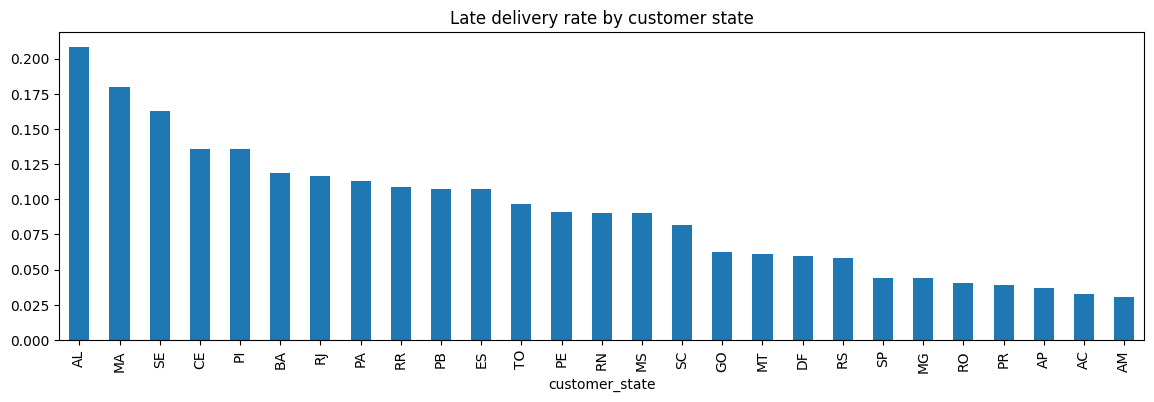

In [5]:
by_state = delivery.groupby("customer_state").agg(
    late_rate=("delivery_delay_days", lambda x: (x > 0).mean()),
    order_count=("order_id", "count")
).sort_values("late_rate", ascending=False)

print(by_state.head(10))
by_state["late_rate"].plot(kind="bar", title="Late delivery rate by customer state", figsize=(14,4))
plt.savefig("../reports/figures/1.1-late-rate-by-state.png", dpi=150)

## Top 20 worst-performing sellers by late rate

In [6]:
by_seller = delivery.groupby("seller_id").agg( late_rate=("is_late", "mean"), order_count=("order_id", "count") ).query("order_count >= 20") # min volume filter 
worst = by_seller.sort_values("late_rate", ascending=False).head(20) 
print(worst)

                                  late_rate  order_count
seller_id                                               
2709af9587499e95e803a6498a5a56e9   0.500000           46
54965bbe3e4f07ae045b90b0b8541f52   0.320988           81
821fb029fc6e495ca4f08a35d51e53a5   0.320000           25
ede0c03645598cdfc63ca8237acbe73d   0.319149           47
ad781527c93d00d89a11eecd9dcad7c1   0.315789           38
7f152321c60a266edc53af1925ef96c1   0.300000           20
2a1348e9addc1af5aaa619b1a3679d6b   0.294118           51
f76a3b1349b6df1ee875d1f3fa4340f0   0.291667           24
054694fa03fe82cec4b7551487331d74   0.285714           21
2e1a7d075abe038c1b2743005fe42ff1   0.272727           22
835f0f7810c76831d6c7d24c7a646d4d   0.270833           48
71039d19d4303bf9054d69e9a9236699   0.236842           38
1dfe5347016252a7884b694d4f10f5c4   0.230769           26
bbad7e518d7af88a0897397ffdca1979   0.226190           84
6ec1a01e866584bb679eb9b098345919   0.225806           31
beadbee30901a7f61d031b6b686095a

## Delivery delay distribution histogram

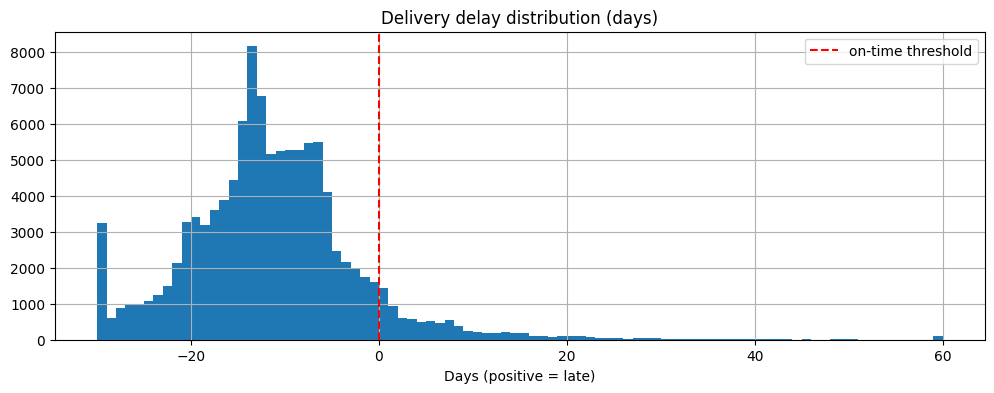

In [7]:
fig, ax = plt.subplots(figsize=(12,4)) 
delivery["delivery_delay_days"].clip(-30,60).hist(bins=90, ax=ax) 
ax.axvline(0, color="red", linestyle="--", label="on-time threshold") 
ax.set_title("Delivery delay distribution (days)") 
ax.set_xlabel("Days (positive = late)") 
plt.legend() 
plt.savefig("../reports/figures/1.1-delay-distribution.png", dpi=150)